In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Варіант 8 — Полтава
CITY = "Poltava"
VARIANT = 8
JULY_TEMP = 21

# Фіксуємо генератор випадкових чисел
np.random.seed(VARIANT)

# Генеруємо 30 денних температур
daily_temps = np.random.normal(
    loc=JULY_TEMP,
    scale=2.5,
    size=30
)

print("Variant:", VARIANT)
print("City:", CITY)
print("July average temperature:", JULY_TEMP, "C")
print("\nDaily temperatures:")
print(daily_temps)

print("\nSample mean:", daily_temps.mean())
print("Sample standard deviation:", daily_temps.std())

Variant: 8
City: Poltava
July average temperature: 21 C

Daily temperatures:
[21.22801179 23.72820683 16.13257423 17.53412617 15.25877106 27.02458576
 25.31959042 26.51139071 22.9870691  23.44105274 18.04143213 25.79090903
 18.191683   19.33991133 20.05410357 19.02096182 23.14887027 20.42302751
 20.83584743 20.47840941 24.36717143 19.48261801 20.56437947 22.06012855
 16.88502474 19.79114763 22.33867063 23.91535122 21.40420777 19.31791518]

Sample mean: 21.15390496434445
Sample standard deviation: 2.9984948253414636


In [3]:
mean = daily_temps.mean()
std = daily_temps.std()

dist = stats.norm(loc=mean, scale=std)

print("Mean (mu):", mean)
print("Standard deviation (sigma):", std)
print("Normal distribution: N(", mean, ",", std, ")")

Mean (mu): 21.15390496434445
Standard deviation (sigma): 2.9984948253414636
Normal distribution: N( 21.15390496434445 , 2.9984948253414636 )


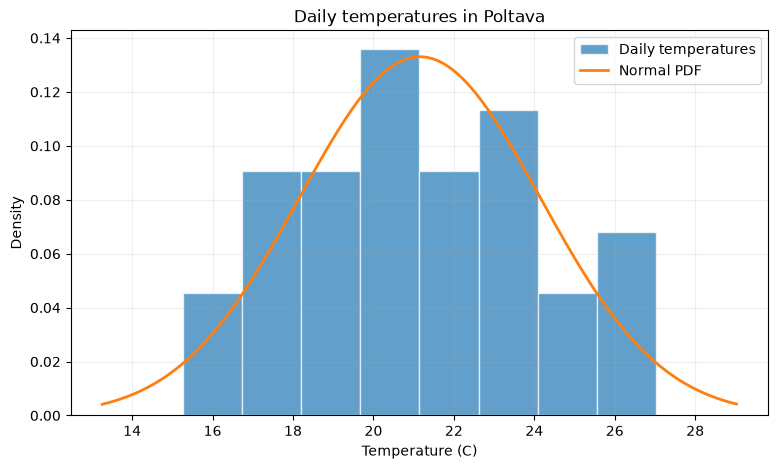

In [4]:
x = np.linspace(
    daily_temps.min() - 2,
    daily_temps.max() + 2,
    200
)

plt.figure(figsize=(9, 5))

plt.hist(
    daily_temps,
    bins=8,
    density=True,
    edgecolor="white",
    alpha=0.7,
    label="Daily temperatures"
)

plt.plot(
    x,
    dist.pdf(x),
    linewidth=2,
    label="Normal PDF"
)

plt.xlabel("Temperature (C)")
plt.ylabel("Density")
plt.title("Daily temperatures in Poltava")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [5]:
lower = mean - std
upper = mean + std

probability = dist.cdf(upper) - dist.cdf(lower)

print("Lower bound:", lower)
print("Upper bound:", upper)
print("Probability:", probability)
print("Percentage:", probability * 100, "%")

Lower bound: 18.155410139002985
Upper bound: 24.152399789685912
Probability: 0.6826894921370859
Percentage: 68.26894921370858 %


In [6]:
percentile_95 = dist.ppf(0.95)

print("95th percentile:", percentile_95, "C")

95th percentile: 26.085990053202575 C


## Письмові відповіді

### 1. Різниця між PDF і CDF

`pdf(x)` повертає значення щільності ймовірності в точці x. 
Вона відповідає на питання: наскільки щільно зосереджені значення розподілу біля певного x.

`cdf(x)` повертає накопичену ймовірність того, що випадкова величина 
буде меншою або дорівнюватиме x. Тобто вона відповідає на питання: 
яка частка значень знаходиться ліворуч від заданого x.

### 2. Чому PDF може бути більшою за 1?

Значення PDF може бути більшим за 1, тому що PDF — це не сама ймовірність, 
а щільність ймовірності. Ймовірність отримується як площа під кривою PDF 
на певному інтервалі. Загальна площа під кривою дорівнює 1, хоча її висота 
в окремій точці може бути більшою за 1.

### 3. Чому PPF є оберненою до CDF?

CDF приймає значення x і повертає накопичену ймовірність:

x → CDF(x)

PPF виконує зворотну операцію: приймає задану накопичену ймовірність 
і повертає значення x, якому вона відповідає:

p → PPF(p)

Наприклад, `dist.ppf(0.95)` знаходить таку температуру, для якої 
`dist.cdf(temperature)` дорівнює 0.95.

In [7]:
print("=== PRACTICE 10 RESULTS ===")
print("Variant:", VARIANT)
print("City:", CITY)
print("July temperature:", JULY_TEMP, "C")
print("Sample size:", len(daily_temps))
print("Mean:", mean)
print("Std:", std)
print("Probability within one std:", probability)
print("95th percentile:", percentile_95, "C")

=== PRACTICE 10 RESULTS ===
Variant: 8
City: Poltava
July temperature: 21 C
Sample size: 30
Mean: 21.15390496434445
Std: 2.9984948253414636
Probability within one std: 0.6826894921370859
95th percentile: 26.085990053202575 C
